# Deep Learning Assignment 3 - Part 1

##  Text Generation

Student 1: Rajaa Haj 322512690

Student 2: Aseel Shaheen 212393532



In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


# *Imports*

In [2]:
import pandas as pd
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import re
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset,DataLoader,TensorDataset
from google.colab import files
import os



## *Study the data:*

### Load the CSV:

we will start by loading the Songs CSV file into Dataframe using pandas and showcase a couple of rows from it.





In [3]:
# Load the data from the csv file
data_path='/content/drive/MyDrive/Songs.csv'
data=pd.read_csv(data_path, encoding='utf-8')
data.head(n=10) # Display the first 10 rows of the data

,Artist,Title,Lyrics
0,Taylor Swift,cardigan,"Vintage tee, brand new phone\nHigh heels on co..."
1,Taylor Swift,exile,"I can see you standing, honey\nWith his arms a..."
2,Taylor Swift,Lover,We could leave the Christmas lights up 'til Ja...
3,Taylor Swift,the 1,"I'm doing good, I'm on some new shit\nBeen say..."
4,Taylor Swift,Look What You Made Me Do,I don't like your little games\nDon't like you...
5,Taylor Swift,betty,"Betty, I won't make assumptions\nAbout why you..."
6,Taylor Swift,august,"Salt air, and the rust on your door\nI never n..."
7,Taylor Swift,End Game,I wanna be your end game\nI wanna be your firs...
8,Taylor Swift,You Need To Calm Down,You are somebody that I don't know\nBut you're...
9,Taylor Swift,ME!,I promise that you'll never find another like ...


1) we will print all of the artist's names and show how many songs are associated with each artists

In [4]:
# count the number of songs assoicated for each artist
artist_song_counts=data['Artist'].value_counts()

for artist, count in artist_song_counts.items():

  print(f"{artist}: {count} songs")

Taylor Swift: 50 songs
Billie Eilish: 50 songs
David Bowie: 50 songs
Billy Joel: 50 songs
Eric Clapton: 50 songs
Leonard Cohen: 50 songs
Bruce Springsteen: 40 songs
The Beatles: 35 songs
Vance Joy: 30 songs
Bryan Adams: 30 songs
Lana Del Rey: 30 songs
Nat King Cole: 30 songs
​twenty one pilots: 30 songs
Elton John: 30 songs
Ray LaMontagne: 30 songs
John Denver: 30 songs
Frank Sinatra: 30 songs
George Michael: 30 songs
Queen: 30 songs
Ed Sheeran: 20 songs
Bob Dylan: 20 songs


2)  We will print the size of the dataset and how many songs are there.

In [5]:
data_size=data.shape

print(f"The size of the dataset is {data_size} \n")
print(f"The number of rows in the dataset is {data_size[0]} \n")
print(f"The number of columns in the dataset is {data_size[1]} \n")

songs_num= len(data)

print(f"The number of songs in the dataset is {songs_num}")



The size of the dataset is (745, 3) 

The number of rows in the dataset is 745 

The number of columns in the dataset is 3 

The number of songs in the dataset is 745


3) We will print the average number of characters and words of a song for all songs lyrics in the dataset ( the average length of a song).



In [6]:
total_char=0
total_words=0


filtered_data=data.dropna(subset=['Lyrics'])

for lyrics in filtered_data['Lyrics']:

  total_char+=len(lyrics)
  total_words+=len(lyrics.split())

avg_char=total_char/songs_num
avg_word=total_words/songs_num


print(f"The average number of characters per song : {avg_char} \n")
print(f"The average number of words per song : {avg_word} \n")

The average number of characters per song : 1403.3476510067114 

The average number of words per song : 276.26040268456376 



4)  We will print the top 3 most used words in the congs and visualize the data using word cloud image .

The Top 3 most used words is:

the : 7458 times 

I : 6719 times 

you : 5475 times 



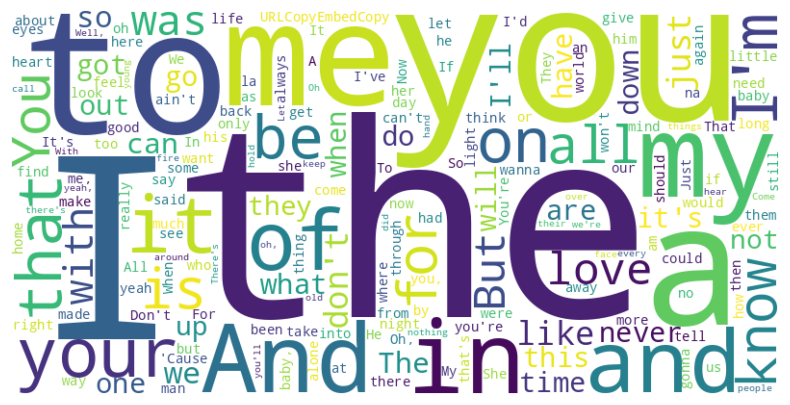

In [7]:

all_lyrics=' '.join(data['Lyrics'].tolist())
all_words=all_lyrics.split()
words_counts=Counter(all_words)

# get the top 3 used words
top_3_words=words_counts.most_common(3)

# print the top 3 used words
print("The Top 3 most used words is:\n")
for word, count in top_3_words:

  print(f"{word} : {count} times \n")


# Display the word cloud

word_cloud=WordCloud(width=800, height =400 , background_color='white').generate_from_frequencies(words_counts)

plt.figure(figsize=(10,5))
plt.imshow(word_cloud , interpolation='bilinear')
plt.axis('off')
plt.show()






# *Preprocessing:*  



*   We add the function **preprocess_data(text)** to clean the text by : removing unnecessary symbols and keep only english letters and  removing extra whitespaces.

  **Note:** By examining the dataset , we notice that at the end of many song lyric, the words : "urlcopyembedcopy" or "embedshare" fequently appear. These words are not part of the actual lyrics , so we remove them during preprocessing.
  

* We apply this function to the dataset and create a corpus from the cleaned lyrics .

*   In order to encode the data before training the model :<br>
1) We start by Tokenizing the Corpus by splitting the cleaned corpus into individual words , then creating a vocabulary dictionary where each word is mapped to numerical index . <br>
2) we convert the words to sequences by replacing each word from the vocab with its corresponding numerical index and create a list of numbers to representing all the corpus .<br>
3) We prepare input_outupt pairs of sequences for training : we define a fixed sequence length (sequence_length=50) and use sliding window approach (step=1)  to ensure sequences overlap. So , each input sequence consists of sequence_length words and the target output is the next word in the sequence .  








In [8]:

def preprocess_data(text):

  if isinstance(text,str):
      text=text.lower()
      # keep only letters and spaces
      text=re.sub(r"[^a-z'\s\n]","",text)
      # remove unwanted artifacts
      text=re.sub(r"urlcopyembedcopy", "", text)
      text=re.sub(r"embedshare","", text)
      # remove extra spaces
      text=re.sub(r"[^\S\n]"," ",text).strip()
      return text

  return ""

# clean the data
data["Prepocessed_Lyrics"]=data["Lyrics"].dropna().apply(preprocess_data)


# create the corpus
corpus=" ".join(data["Prepocessed_Lyrics"].dropna())



#Encode the data
#step 1: Tokenize the text
#words= corpus.strip()
words=re.findall(r"\S+|\n",corpus)
# step 2: Create a vocabulary from unique words
word_counts=Counter(words)  # count occurrences of each word
# create a sorted vocabulary
vocab=sorted(word_counts.keys())

# step 3: create mapping from words to index
word_to_index={ word:i for i, word in enumerate(vocab)}
index_to_word={i: word for word,i in word_to_index.items()}

# step 4: encode all the corpus into a list of numbers
encoded_corpus=[word_to_index[word] for word in words]

# step 5: Prepare Sequences
sequence_length=50
step=1 # to ensure overlapping sequences
input_sequences=[]
target_sequences=[]

for i in range(0,len(encoded_corpus)-sequence_length,step):

  sequence=(encoded_corpus[i:i+sequence_length])
  target=(encoded_corpus[i+sequence_length])

  if len(sequence) < sequence_length:
    sequence+=[0]* (sequence_length-len(sequence))


  input_sequences.append(sequence)
  target_sequences.append(target)


  # input_sequences.append(encoded_corpus[i:i+sequence_length])  # input sequence of size sequence length
  # target_sequences.append(encoded_corpus[i+sequence_length])   # next word as target







# *Model Definition and training :*

## *Define The Model:*

We will use LSTM model to handle sequential data .
We choose the loss function :
The Optimizer :


In [9]:
class LSTMModel(nn.Module):


  def __init__(self, vocab_size, embedding_dim=100, hidden_dim=128,num_layers=2):

    super(LSTMModel, self).__init__()
    self.embedding=nn.Embedding(vocab_size, embedding_dim)
    self.lstm=nn.LSTM(embedding_dim,hidden_dim,num_layers,batch_first=True)
    self.fc=nn.Linear(hidden_dim,vocab_size)


  def forward(self,x):

    embedded=self.embedding(x)
    lstm_out,_=self.lstm(embedded)
    output=self.fc(lstm_out[:,-1,:])

    return output




## Train the model :

In [10]:
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")

# convert to PyTorch tensors
X=torch.tensor(input_sequences, dtype=torch.long)
y=torch.tensor(target_sequences,dtype=torch.long)


batch_size=64
dataset=TensorDataset(X,y)
dataloader=DataLoader(dataset,batch_size=batch_size , shuffle=True )



vocab_size=len(vocab)
model=LSTMModel(vocab_size).to(device)
criterion= nn.CrossEntropyLoss()
learning_rate=0.001
optimizer=optim.Adam(model.parameters(), lr=learning_rate)

print("training the model ......")

num_epochs=100
losses=[]
for epoch in range(num_epochs):
    total_loss=0
    for batch_X,batch_y in dataloader:
      batch_X,batch_y=batch_X.to(device),batch_y.to(device)
      optimizer.zero_grad()
      outputs=model(batch_X)
      loss=criterion(outputs,batch_y)
      loss.backward()
      optimizer.step()
      total_loss+=loss.item()
    avg_loss=total_loss/len(dataloader)

    losses.append(avg_loss)
    print(f"Epoch[{ epoch+1}/{num_epochs}],Loss: {avg_loss:.4f}")


model_path='/content/drive/MyDrive/lstm_model1.pth'

# if os.path.exists(model_path):

#       print("loading model....")
#       model.load_state_dict(torch.load(model_path))
#       model.to(device)

# else:

#       print("training the model ......")

#       num_epochs=100
#       losses=[]
#       for epoch in range(num_epochs):
#           total_loss=0
#           for batch_X,batch_y in dataloader:
#             batch_X,batch_y=batch_X.to(device),batch_y.to(device)
#             optimizer.zero_grad()
#             outputs=model(batch_X)
#             loss=criterion(outputs,batch_y)
#             loss.backward()
#             optimizer.step()
#             total_loss+=loss.item()
#           avg_loss=total_loss/len(dataloader)

#           losses.append(avg_loss)
#           print(f"Epoch[{ epoch+1}/{num_epochs}],Loss: {avg_loss:.4f}")




      # torch.save(model.state_dict(),model_path)
      # files.download(model_path)











training the model ......
Epoch[1/100],Loss: 5.5180
Epoch[2/100],Loss: 4.8398
Epoch[3/100],Loss: 4.4537
Epoch[4/100],Loss: 4.1295
Epoch[5/100],Loss: 3.8507
Epoch[6/100],Loss: 3.6050
Epoch[7/100],Loss: 3.3871
Epoch[8/100],Loss: 3.1935
Epoch[9/100],Loss: 3.0190
Epoch[10/100],Loss: 2.8677
Epoch[11/100],Loss: 2.7316
Epoch[12/100],Loss: 2.6064
Epoch[13/100],Loss: 2.4959
Epoch[14/100],Loss: 2.3932
Epoch[15/100],Loss: 2.2994
Epoch[16/100],Loss: 2.2150
Epoch[17/100],Loss: 2.1335
Epoch[18/100],Loss: 2.0601
Epoch[19/100],Loss: 1.9905
Epoch[20/100],Loss: 1.9267
Epoch[21/100],Loss: 1.8664
Epoch[22/100],Loss: 1.8116
Epoch[23/100],Loss: 1.7589
Epoch[24/100],Loss: 1.7097
Epoch[25/100],Loss: 1.6632
Epoch[26/100],Loss: 1.6196
Epoch[27/100],Loss: 1.5796
Epoch[28/100],Loss: 1.5423
Epoch[29/100],Loss: 1.5053
Epoch[30/100],Loss: 1.4703
Epoch[31/100],Loss: 1.4375
Epoch[32/100],Loss: 1.4071
Epoch[33/100],Loss: 1.3788
Epoch[34/100],Loss: 1.3507
Epoch[35/100],Loss: 1.3258
Epoch[36/100],Loss: 1.3016
Epoch[37/10

plot

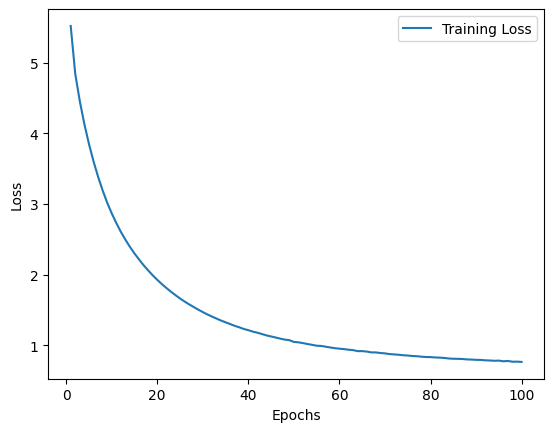

In [11]:
plt.plot(range(1,num_epochs+1) , losses ,label="Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

## **Evaluation:**

In [12]:
def load_trained_model(model_path, vocab_size):

  model=LSTMModel(vocab_size)
  model.load_state_dict(torch.load(model_path))
  model.to(device)
  model.eval()
  return model


In [13]:
# Function to generated lyrics with different strategies

def sample_with_temperature(predictions , temperature=1.2):

  predictions=predictions/temperature
  probabilities=torch.nn.functional.softmax(predictions,dim=0)
  return torch.multinomial(probabilities,1).item()



def sample_with_top_p(prediction, top_p=0.8):

   sorted_indx=torch.argsort(prediction,descending=True)
   sorted_prob=torch.nn.functional.softmax(prediction[sorted_indx],dim=0)
   cum_prop=torch.cumsum(sorted_prob,dim=0)
   filtered_indx=sorted_indx[cum_prop<=top_p]

   if len(filtered_indx)==0:
    filtered_indx=sorted_indx


   selected_indx=filtered_indx[torch.multinomial(sorted_prob[:len(filtered_indx)],1)].item()

   return selected_indx




In [17]:
# def LyricsGenerator(starting_string , char_count , strategy="argmax", temp=1.2 , top_k=5 , top_p=0.90):

#   #model=load_trained_model(model_path,vocab_size)
#   model.eval()
#   words=preprocess_data(starting_string)
#   words=words.lower().split()

#   #words=starting_string.lower().split()
#   generated_lyrics=words[:]

#   #print(generated_lyrics)


#   ## convert words to indx
#   #input_seq=[word_to_index[word] for word in words if word in word_to_index ]
#   input_seq=[word_to_index[word] for word in words]
#   input_seq=torch.tensor(input_seq,dtype=torch.long).unsqueeze(0).to(device)



#   while len("".join(generated_lyrics)) < char_count:

#     with torch.no_grad():

#         output=model(input_seq)
#         #predicted_index=torch.argmax(output,dim=1).item()
#         #predicted_word=index_to_word.get(predicted_index,"")
#         #generated_lyrics.append(predicted_word)
#         predictions=output.squeeze(0)

#         if strategy=="temperature":

#            predicted_index=sample_with_temperature(predictions,temp)

#         elif strategy=="top_k":

#             top_values,top_indices=torch.topk(predictions,k=top_k)
#             predicted_index=top_indices[torch.multinomial(torch.nn.functional.softmax(top_values,dim=-1),1)].item()

#         elif strategy=="top_p":

#             predicted_index=sample_with_top_p(predictions,top_p)


#         else:

#             predicted_index=torch.argmax(output,dim=1).item()


#         predicted_word=index_to_word.get(predicted_index,"")
#         generated_lyrics.append(predicted_word)
#         #update input sequence
#         if input_seq.shape[1]>1:
#           input_seq=torch.cat([input_seq[:,1:], torch.tensor([[predicted_index]],dtype=torch.long).to(device)],dim=1)

#         else:

#           input_seq=torch.tensor([[predicted_index]])






#   return " ".join(generated_lyrics)


def LyricsGenerator(starting_string , char_count , strategy="argmax", temp=1.2 , top_k=5 , top_p=0.90):

  model.eval()
  words=preprocess_data(starting_string)
  words=words.lower().split()

  #words=starting_string.lower().split()
  #generated_lyrics=words[:]

  #print(generated_lyrics)


  ## convert words to indx
  #input_seq=[word_to_index[word] for word in words if word in word_to_index ]
  # input_seq=[word_to_index[word] for word in words]
  # input_seq=torch.tensor(input_seq,dtype=torch.long).unsqueeze(0).to(device)
  input_indx=[word_to_index.get(word,0) for word in words]

  generated=starting_string
  #input_seq=torch.tensor(word_to_index.get(word,0) for word in words)

  with torch.no_grad():
    for _ in range(int(char_count)):

      input_tensor=input_tensor=torch.tensor([input_indx],dtype=torch.long).to(device)

      output=model(input_tensor)
      pred_indx=torch.argmax(output,dim=1).item()
      pred_word=index_to_word.get(pred_indx,"")
      generated+=" "+pred_word

      input_indx.append(pred_indx)

      if len(generated) >= char_count:
        break

    return generated





print("Generated Song 1:")
print("strategy : temp")
generated_song1=LyricsGenerator("it's not a silly little moment...",avg_char,strategy="temperature")
print(generated_song1)
print("strategy : top_k")
generated_song2=LyricsGenerator("it's not a silly little moment...",avg_char,strategy="top_k")
print(generated_song2)

generated_song3=LyricsGenerator("it's not a silly little moment...",avg_char,strategy="argmax")
print(generated_song3)

print("strategy : top_p")
generated_song4=LyricsGenerator("it's not a silly little moment...",avg_char,strategy="top_p")
print(generated_song4)

# print("\nGenerated Song 2:")
# generated_song2=LyricsGenerator("")


# print("Generated Song 3:")
# generated_song3=LyricsGenerator(" ",avg_char)
# print(generated_song3)



Generated Song 1:
strategy : temp
it's not a silly little moment... 
 you'll believe someone 
 didn't care when you won't 
 lay me down in sight 
 
 don't let me down 
 let me love you let me go no love 
 don't let me down don't let me down 
 
 build me and me baby 
 say feels to me 
 
 and baby come on and ride the number boy 
 but i ain't got a boy striking matches tall 
 you see my love feels one to be a match knows 
 
 in the avenue of the penitentiary 
 i saw a beggar sold 
 and the next more thin mister nights 
 hello once i am lost in line 
 
 we were runnin' in a new by a are on a week 
 a poor man was born to be found most the year 
 he says son and i saw a bartender 
 he was blinded by the light 
 very a song i'm just under my skin 
 and it's once that we bought it's not a chance 
 so goodbye is just to get up the same 
 i see fire burning watchin' their greatest band 
 well it's getting electric hungry and mr rolling day 
 and he went on the day about the break of this song 